In [1]:
# --- imports + setup ---
# run this script every time!

import torch
import numpy as np

from controller import LSTMController
from utils import plot_activations, plot_activations_multi
from matplotlib import pyplot as plt

import sys
sys.path.append('..')

from QMC_mouseUSV.subglottal_pressure import subglottal_pressure
from QMC_mouseUSV.glottal_area import glottal_area
from QMC_mouseUSV.impingement_length import impingement_length
from QMC_mouseUSV.jet_speed import jet_speed_from_pressure
from QMC_mouseUSV.USVfreq import USVfreq

# in model.ipynb, add this to your setup/imports cell
import pickle

with open("../data_prep/pkl-files/pca_model.pkl", "rb") as f:
    pca_full = pickle.load(f)

with open("../data_prep/pkl-files/sample_trajectories.pkl", "rb") as f:
    sample_trajectories = pickle.load(f)

print(f"loaded {len(sample_trajectories)} sample trajectories, shape of first:", sample_trajectories[0].shape)

print("loaded pca model, n_components available:", pca_full.n_components_)
print("imports completed!")

loaded 10 sample trajectories, shape of first: (100,)
loaded pca model, n_components available: 100
imports completed!


In [2]:
# --- pick one real trajectory ---
real_trajectory = sample_trajectories[0]  # shape (100,)

# --- center it the same way PCA was fit (subtract its own mean) ---
real_trajectory_centered = real_trajectory - real_trajectory.mean()

# --- project into PCA space, keep only the first 10 components ---
real_pca_vector = pca_full.transform(real_trajectory_centered.reshape(1, -1))[:, :10]
pca_vector = torch.tensor(real_pca_vector, dtype=torch.float32)
print("pca_vector shape:", pca_vector.shape)

# --- real target: the ACTUAL trajectory, uncentered ---
real_target_f0 = torch.tensor(real_trajectory, dtype=torch.float32).unsqueeze(0)
print("real_target_f0 shape:", real_target_f0.shape)

pca_vector shape: torch.Size([1, 10])
real_target_f0 shape: torch.Size([1, 100])


In [12]:
model = LSTMController(pca_dim=10)
# --- get real input from sample_trajectories: batch size 1 ---
#pca_vector = torch.randn(1, 10)  # random placeholder PCA vector
pca_vector = torch.tensor(pca_full.transform(
    (sample_trajectories[0] - sample_trajectories[0].mean()).reshape(1, -1)
)[:, :10], dtype=torch.float32)

# --- forward pass through the LSTM ---
activations = model(pca_vector)
print("lstm output shape: " + str(activations.shape))

# unpacking the 4 channels in the order defined in controller.py
# (resp, PCAIA, CT, TA)
resp_activity = activations[..., 0]
PCAIA_activity = activations[..., 1]
CT_activity = activations[..., 2]
TA_activity = activations[..., 3]

# --- run thru the ported hakansson et al. model ---
pressure = subglottal_pressure(resp_activity)
g_area = glottal_area(PCAIA_activity, TA_activity)
imp_length = impingement_length(CT_activity, TA_activity)
speed = jet_speed_from_pressure(g_area, pressure)
predicted_f0 = USVfreq(speed, imp_length)

print("predicted f0 shape: " + str(predicted_f0.shape))
print("predicted f0 sample values: " + str(predicted_f0[0, :5]))

# --- loss & backward ---
# **REMINDER TO TRY OTHER LOSSES HERE (mse is like my default im sure there are other better ones)
#loss = torch.nn.functional.mse_loss(predicted_f0, real_target_f0)
# switched from mse to rmse loss
predicted_f0_khz = predicted_f0 / 1000
target_f0_khz = real_target_f0 / 1000
loss = torch.sqrt(torch.nn.functional.mse_loss(predicted_f0_khz, target_f0_khz))
print("loss: " + str(loss.item()) + " kHz (RMSE)")

loss.backward()

# --- check gradients actually reached the lstm's weights ---
for name, param in model.named_parameters():
    if param.grad is None:
        print("no gradient for " + name)
    else:
        print(f"{name}: grad norm = {param.grad.norm().item():.6f}")


lstm output shape: torch.Size([1, 100, 4])
predicted f0 shape: torch.Size([1, 100])
predicted f0 sample values: tensor([65117.2422, 66551.2266, 66774.6719, 66805.5234, 66809.7109],
       grad_fn=<SliceBackward0>)
loss: 32.69046401977539 kHz (RMSE)
embedding.weight: grad norm = 0.000072
embedding.bias: grad norm = 0.000000
lstm.weight_ih_l0: grad norm = 0.000171
lstm.weight_hh_l0: grad norm = 0.000000
lstm.bias_ih_l0: grad norm = 0.000000
lstm.bias_hh_l0: grad norm = 0.000000
fc.weight: grad norm = 162.174759
fc.bias: grad norm = 42.227898


epoch 0: loss = 18.66196 kHz
epoch 20: loss = 3.52798 kHz
epoch 40: loss = 0.98461 kHz
epoch 60: loss = 0.42107 kHz
epoch 80: loss = 0.42057 kHz
epoch 100: loss = 0.40506 kHz
epoch 120: loss = 0.40019 kHz
epoch 140: loss = 0.39594 kHz
epoch 160: loss = 0.39162 kHz
epoch 180: loss = 0.38701 kHz
epoch 200: loss = 0.38214 kHz
epoch 220: loss = 0.37702 kHz
epoch 240: loss = 0.37167 kHz
epoch 260: loss = 0.36610 kHz
epoch 280: loss = 0.36033 kHz
final loss: 0.35 kHz


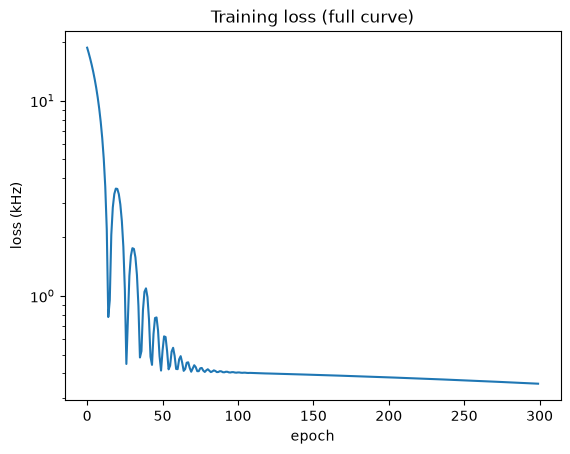

predicted f0 range:96542.2890625 - 99511.75 Hz
target f0 range:99257.8125 - 99609.375 Hz
beta range: 0.5591141581535339 0.5645471215248108


In [9]:
model = LSTMController(pca_dim=10)

# --- training loop with completely synethetic target f0 ---

# lr = 1e-2 works well w MSE loss @ 300 epochs
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

real_trajectory = sample_trajectories[0]
real_trajectory_centered = real_trajectory - real_trajectory.mean()
real_pca_vector = pca_full.transform(real_trajectory_centered.reshape(1, -1))[:, :10]
pca_vector = torch.tensor(real_pca_vector, dtype=torch.float32)

real_target_f0 = torch.tensor(real_trajectory, dtype=torch.float32).unsqueeze(0)

losses = []

for epoch in range(300):
    optimizer.zero_grad()

    activations = model(pca_vector)
    resp_activity = activations[..., 0]
    PCAIA_activity = activations[..., 1]
    CT_activity = activations[..., 2]
    TA_activity = activations[..., 3]

    pressure = subglottal_pressure(resp_activity)
    g_area = glottal_area(PCAIA_activity, TA_activity)
    imp_length = impingement_length(CT_activity, TA_activity)
    speed = jet_speed_from_pressure(g_area, pressure)
    predicted_f0 = USVfreq(speed, imp_length)

    predicted_f0_khz = predicted_f0 / 1000
    target_f0_khz = real_target_f0 / 1000
    loss = torch.sqrt(torch.nn.functional.mse_loss(predicted_f0_khz, target_f0_khz))

    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if epoch % 20 == 0:
        print(f"epoch {epoch}: loss = {loss.item():.5f} kHz")

print(f"final loss: {losses[-1]:.2f} kHz")

# graph loss over time
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("loss (kHz)")
plt.yscale("log")  # helpful when values span multiple orders of magnitude
plt.title("Training loss (full curve)")
plt.show()

# check the mucsle activations after training
with torch.no_grad():
    activations_start_check = model(pca_vector)
    pred_check = USVfreq(
        jet_speed_from_pressure(
            glottal_area(activations_start_check[...,1], activations_start_check[...,3]),
            subglottal_pressure(activations_start_check[...,0])
        ),
        impingement_length(activations_start_check[...,2], activations_start_check[...,3])
    )
    print("predicted f0 range:" + str(pred_check.min().item()) + " - " + str(pred_check.max().item()) + " Hz")
    print("target f0 range:" + str(real_target_f0.min().item()) + " - " + str(real_target_f0.max().item()) + " Hz")

    g_area_check = glottal_area(activations_start_check[...,1], activations_start_check[...,3])
    tracheal_diameter = 2 * torch.sqrt(torch.tensor(0.95e-6) / torch.pi)
    glottal_diameter = 2 * torch.sqrt(g_area_check / torch.pi)
    beta_check = glottal_diameter / tracheal_diameter
    print("beta range:", beta_check.min().item(), beta_check.max().item())

In [9]:
# get one real pca vector working

with open("../data_prep/pkl-files/sample_trajectories.pkl", "rb") as f:
    sample_trajectories = pickle.load(f)

print(f"Loaded {len(sample_trajectories)} sample trajectories, shape of first:", sample_trajectories[0].shape)

Loaded 10 sample trajectories, shape of first: (100,)
